# Dykstra's Algorithm: Projections onto Convex Sets

Finding a point in the **intersection of convex sets** $C_1 \cap C_2 \cap \cdots \cap C_m$ is a fundamental problem in optimization, signal processing, and machine learning. When only **projections** $P_{C_i}$ onto each individual set are available, iterative projection methods provide elegant solutions.

## Alternating Projections (POCS)

The simplest method is the **method of alternating projections** (von Neumann, Bregman), also known as POCS (Projections Onto Convex Sets):
$$
x_{k+1} = P_{C_2}(P_{C_1}(x_k)).
$$
For two **closed convex** sets with non-empty intersection, this converges to *a* point in $C_1 \cap C_2$, but not necessarily to the projection of the initial point $x_0$ onto the intersection.

## Dykstra's Algorithm

**Dykstra's algorithm** (1983) finds the projection of $x_0$ onto $C_1 \cap C_2$ by adding **incremental corrections** $p_k, q_k \in \mathbb{R}^d$:
$$
y_{k+1} = P_{C_1}(x_k + p_k), \quad p_{k+1} = x_k + p_k - y_{k+1},
$$
$$
x_{k+1} = P_{C_2}(y_{k+1} + q_k), \quad q_{k+1} = y_{k+1} + q_k - x_{k+1}.
$$
The corrections $p_k, q_k$ accumulate the "overshot" from each projection step. Dykstra's algorithm **converges to $P_{C_1 \cap C_2}(x_0)$**, the closest point in the intersection to the starting point — something alternating projections cannot guarantee.

Both algorithms generalize to multiple sets and are widely used in constrained optimization, image reconstruction, machine learning (constraint satisfaction), and signal recovery.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, Dropdown, IntSlider

plt.rcParams["figure.dpi"] = 120

## Projection operators

We work in $\mathbb{R}^2$ (or $\mathbb{C} \cong \mathbb{R}^2$) and implement projections onto several convex sets:
- **Disk** $\{x : \|x - c\| \leq r\}$: $P(x) = c + r \frac{x-c}{\|x-c\|}$ if $\|x-c\| > r$, else $x$.
- **Half-plane** $\{x : \langle x, u \rangle \leq 0\}$: $P(x) = x - \langle x, u\rangle_+ \frac{u}{\|u\|^2}$.
- **Hyperplane** $\{x : \langle x, u \rangle = 0\}$: $P(x) = x - \langle x, u \rangle \frac{u}{\|u\|^2}$.
- **Box** $[a_1,b_1] \times [a_2,b_2]$: component-wise clipping.

In [2]:
def proj_disk(x, c, r):
    """Project x onto closed disk of center c and radius r."""
    d = x - c
    norm = np.linalg.norm(d)
    return c + r * d / norm if norm > r else x.copy()


def proj_halfplane(x, u):
    """Project x onto {x: <x,u> <= 0}."""
    dot = np.dot(x, u)
    return x - max(0, dot) * u / np.dot(u, u)


def proj_hyperplane(x, u):
    """Project x onto {x: <x,u> = 0}."""
    return x - np.dot(x, u) * u / np.dot(u, u)


def proj_box(x, lo, hi):
    return np.clip(x, lo, hi)


print("Projection operators ready.")

Projection operators ready.


## POCS vs Dykstra: geometric illustration

We compare the two algorithms on an intersection of a **disk** and a **half-plane**, starting from multiple initial points. The true projection $P_{C_1 \cap C_2}(x_0)$ is shown as a star. Dykstra converges to it; POCS converges to *a* point in the intersection, which may differ.

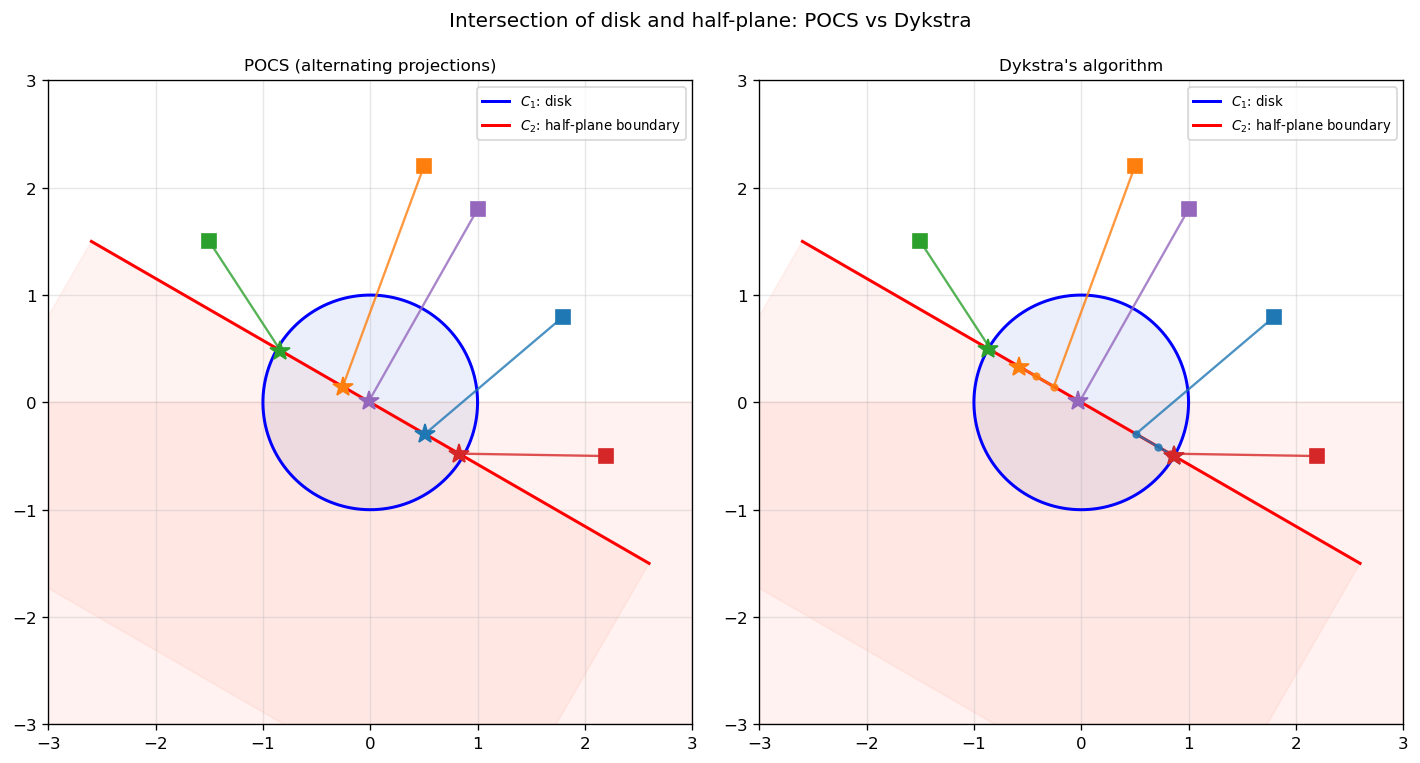

In [3]:
def run_pocs(P1, P2, x0, niter=30):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(niter):
        x = P1(x)
        x = P2(x)
        traj.append(x.copy())
    return np.array(traj)


def run_dykstra(P1, P2, x0, niter=30):
    x = x0.copy()
    p = np.zeros_like(x)
    q = np.zeros_like(x)
    traj = [x.copy()]
    for _ in range(niter):
        y = P1(x + p)
        p = x + p - y
        x = P2(y + q)
        q = y + q - x
        traj.append(x.copy())
    return np.array(traj)


# Sets: disk of radius 1 centered at 0, and half-plane <x, u> <= 0
c_disk = np.array([0.0, 0.0])
r_disk = 1.0
u_half = np.array([np.cos(np.pi/3), np.sin(np.pi/3)])

P1 = lambda x: proj_disk(x, c_disk, r_disk)
P2 = lambda x: proj_halfplane(x, u_half)

# Starting points
starts = [
    np.array([1.8,  0.8]),
    np.array([0.5,  2.2]),
    np.array([-1.5, 1.5]),
    np.array([2.2,  -0.5]),
    np.array([1.0,  1.8]),
]
colors_s = [plt.cm.tab10(i) for i in range(len(starts))]

theta = np.linspace(0, 2*np.pi, 300)
circle_pts = np.column_stack([np.cos(theta), np.sin(theta)])
# half-plane boundary line: <x,u>=0 => x in span of u_perp
u_perp = np.array([-u_half[1], u_half[0]])
line_pts = np.array([-3*u_perp, 3*u_perp])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (algo, run_fn) in zip(axes,
        [("POCS (alternating projections)", run_pocs),
         ("Dykstra's algorithm", run_dykstra)]):
    ax.fill(circle_pts[:,0], circle_pts[:,1], alpha=0.10, color="royalblue")
    ax.plot(circle_pts[:,0], circle_pts[:,1], 'b', lw=1.8, label="$C_1$: disk")
    ax.fill_between([-3, 3], [-3, -3], [0, 0],
                    alpha=0.08, color="tomato", transform=ax.transData)
    ax.plot(line_pts[:,0], line_pts[:,1], 'r', lw=1.8, label="$C_2$: half-plane boundary")
    ax.fill(
        np.append(line_pts[:,0], line_pts[:,0][::-1] - 3*u_half[0]),
        np.append(line_pts[:,1], line_pts[:,1][::-1] - 3*u_half[1]),
        alpha=0.07, color="tomato"
    )
    for x0, col in zip(starts, colors_s):
        traj = run_fn(P1, P2, x0, niter=25)
        ax.plot(traj[:,0], traj[:,1], '-o', ms=4, lw=1.4, color=col, alpha=0.8)
        ax.plot(*x0, 's', ms=8, color=col)
        ax.plot(*traj[-1], '*', ms=12, color=col)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(algo, fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Intersection of disk and half-plane: POCS vs Dykstra", y=1.02)
plt.tight_layout()
plt.show()

## Convergence comparison

For non-intersecting sets, POCS oscillates between closest points. For intersecting sets, we measure the distance to the intersection $\|x_k - P_{C_1 \cap C_2}(x_0)\|$. Dykstra converges to the true projection; POCS may settle at a different point.

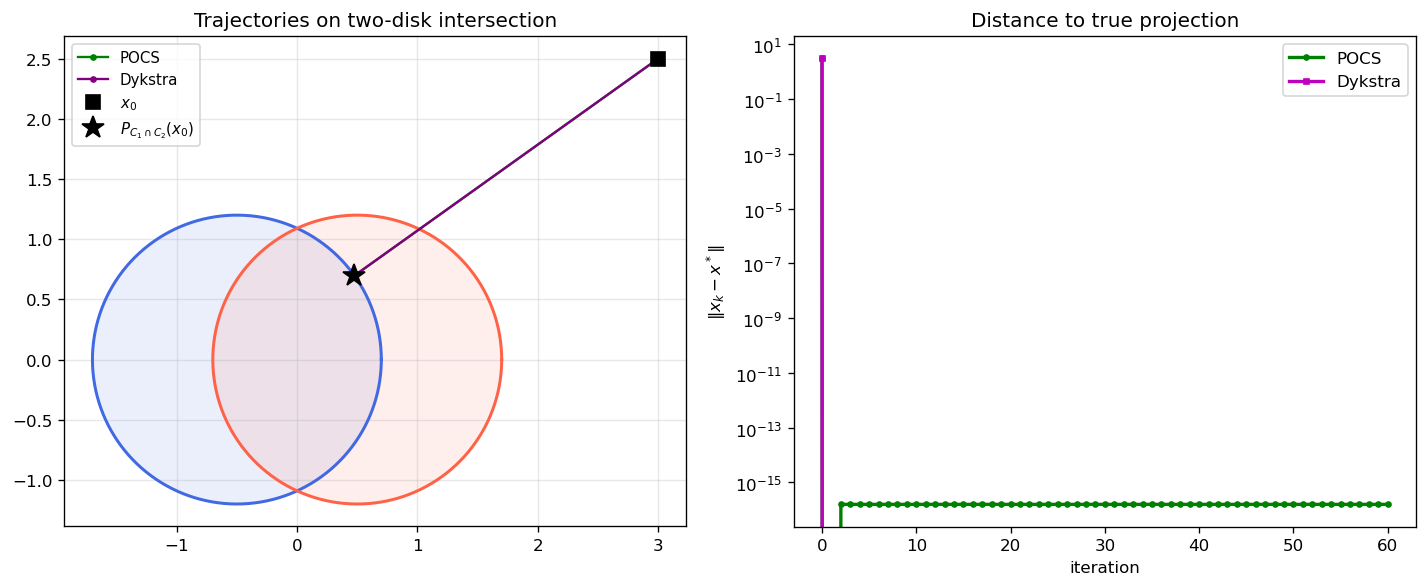

In [4]:
# Two disks with non-empty intersection
c1 = np.array([-0.5, 0.0]); r1 = 1.2
c2 = np.array([ 0.5, 0.0]); r2 = 1.2

Pa = lambda x: proj_disk(x, c1, r1)
Pb = lambda x: proj_disk(x, c2, r2)

x0_conv = np.array([3.0, 2.5])
niter_conv = 60

traj_pocs  = run_pocs(Pa, Pb, x0_conv, niter_conv)
traj_dyk   = run_dykstra(Pa, Pb, x0_conv, niter_conv)

# Ground truth: run Dykstra for much longer
x_star = run_dykstra(Pa, Pb, x0_conv, 2000)[-1]

err_pocs = np.linalg.norm(traj_pocs - x_star, axis=1)
err_dyk  = np.linalg.norm(traj_dyk  - x_star, axis=1)

# Visualization
theta = np.linspace(0, 2*np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# trajectories
ax = axes[0]
for center, radius, color in [(c1, r1, "royalblue"), (c2, r2, "tomato")]:
    ax.fill(center[0] + radius*np.cos(theta),
            center[1] + radius*np.sin(theta), alpha=0.1, color=color)
    ax.plot(center[0] + radius*np.cos(theta),
            center[1] + radius*np.sin(theta), color=color, lw=1.8)
for traj, col, lbl in [(traj_pocs, "green", "POCS"),
                        (traj_dyk,  "purple", "Dykstra")]:
    ax.plot(traj[:,0], traj[:,1], '-o', ms=3, lw=1.4, color=col, label=lbl)
ax.plot(*x0_conv, 'ks', ms=8, label="$x_0$")
ax.plot(*x_star, 'k*', ms=14, label="$P_{C_1\\cap C_2}(x_0)$")
ax.set_aspect("equal"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title("Trajectories on two-disk intersection")

# convergence
axes[1].semilogy(err_pocs, 'g-o', ms=3, lw=2, label="POCS")
axes[1].semilogy(err_dyk,  'm-s', ms=3, lw=2, label="Dykstra")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel(r"$\|x_k - x^*\|$")
axes[1].set_title("Distance to true projection")
axes[1].legend()
plt.tight_layout()
plt.show()

## Interactive: choose constraint pair

Explore several pairs of convex sets and see how the two algorithms navigate to their respective fixed points.

In [5]:
SCENARIOS = {
    "disk ∩ half-plane": (
        lambda x: proj_disk(x, np.array([0.,0.]), 1.0),
        lambda x: proj_halfplane(x, np.array([np.cos(np.pi/3), np.sin(np.pi/3)])),
        3.0,
    ),
    "two disks": (
        lambda x: proj_disk(x, np.array([-0.5, 0.]), 1.2),
        lambda x: proj_disk(x, np.array([ 0.5, 0.]), 1.2),
        3.5,
    ),
    "disk ∩ hyperplane": (
        lambda x: proj_disk(x, np.array([0.5, 0.3]), 1.0),
        lambda x: proj_hyperplane(x, np.array([1., 0.5])/np.linalg.norm([1., 0.5])),
        3.0,
    ),
    "two half-planes": (
        lambda x: proj_halfplane(x, np.array([np.cos(np.pi/4), np.sin(np.pi/4)])),
        lambda x: proj_halfplane(x, np.array([np.cos(-np.pi/4+np.pi), np.sin(-np.pi/4+np.pi)])),
        3.0,
    ),
}

def show_scenario(scenario="disk ∩ half-plane", niter=20):
    P1s, P2s, axlim = SCENARIOS[scenario]
    starts_s = [
        np.array([axlim*0.8, axlim*0.6]),
        np.array([-axlim*0.7, axlim*0.5]),
        np.array([axlim*0.5, -axlim*0.8]),
        np.array([-axlim*0.6, -axlim*0.5]),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    for ax, (algo, run_fn) in zip(axes, [("POCS", run_pocs), ("Dykstra", run_dykstra)]):
        for x0, col in zip(starts_s, ["tab:blue","tab:orange","tab:green","tab:red"]):
            traj = run_fn(P1s, P2s, x0, niter)
            ax.plot(traj[:,0], traj[:,1], '-o', ms=4, lw=1.5, color=col, alpha=0.85)
            ax.plot(*x0, 's', ms=7, color=col)
            ax.plot(*traj[-1], '*', ms=11, color=col)
        ax.set_xlim(-axlim, axlim); ax.set_ylim(-axlim, axlim)
        ax.set_aspect("equal"); ax.grid(alpha=0.3)
        ax.set_title(algo)
    fig.suptitle(scenario, y=1.02)
    plt.tight_layout(); plt.show()

interact(
    show_scenario,
    scenario=Dropdown(options=list(SCENARIOS.keys()), description="sets"),
    niter=IntSlider(value=20, min=2, max=60, step=2, description="iters"),
);

interactive(children=(Dropdown(description='sets', options=('disk ∩ half-plane', 'two disks', 'disk ∩ hyperpla…

## Bibliographical resources

- Dykstra, R. L. (1983). An algorithm for restricted least squares regression. *Journal of the American Statistical Association*, 78(384), 837–842.
- Boyle, J. P. and Dykstra, R. L. (1986). A method for finding projections onto the intersection of convex sets in Hilbert spaces. *Lecture Notes in Statistics*, 37, 28–47.
- Bauschke, H. H. and Borwein, J. M. (1994). Dykstra's alternating projection algorithm for two sets. *Journal of Approximation Theory*, 79(3), 418–443.
- Combettes, P. L. (1994). Inconsistent signal feasibility problems: least-squares solutions in a product space. *IEEE Transactions on Signal Processing*, 42(11), 2955–2966.
- Bauschke, H. H. and Combettes, P. L. (2011). *Convex Analysis and Monotone Operator Theory in Hilbert Spaces*. Springer.